In [ ]:
# CELL 1: Mount Google Drive and Setup Folders
from google.colab import drive
import os

drive.mount('/content/drive')

# Create project folders
folders = [
    '/content/drive/MyDrive/ids_project',
    '/content/drive/MyDrive/ids_project/data',
    '/content/drive/MyDrive/ids_project/models',
    '/content/drive/MyDrive/ids_project/visualizations',
    '/content/drive/MyDrive/ids_project/reports'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✓ Created: {folder}")

print("\n✅ Project structure created in Google Drive!")

Mounted at /content/drive
✓ Created: /content/drive/MyDrive/ids_project
✓ Created: /content/drive/MyDrive/ids_project/data
✓ Created: /content/drive/MyDrive/ids_project/models
✓ Created: /content/drive/MyDrive/ids_project/visualizations
✓ Created: /content/drive/MyDrive/ids_project/reports

✅ Project structure created in Google Drive!


In [1]:
# CELL 2: Install Required Libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries installed and imported!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {__import__('sklearn').__version__}")


✅ All libraries installed and imported!
NumPy version: 2.0.2
Pandas version: 2.2.2
Scikit-learn version: 1.6.1


In [2]:
# CELL 3: Download CIC-IDS-2017 Dataset
import os
import gdown
import zipfile

dataset_path = '/content/drive/MyDrive/ids_project/data'

print("Downloading CIC-IDS-2017 Dataset...")
print("="*60)


url = "https://www.unb.ca/cic/datasets/ids-2017.html"
print(f"\n⚠️ The full dataset is available at: {url}")
print("\nFor this project, we'll load a sample if the full dataset isn't available.")


try:
    import kagglehub
    print("\nTrying to download via kagglehub...")
    path = kagglehub.dataset_download("shadman1028/cicids2017-official-flow-feature-csv-files")
    print(f"✅ Dataset downloaded to: {path}")

    # Copy files to drive
    import shutil
    for file in os.listdir(path):
        if file.endswith('.csv'):
            shutil.copy(os.path.join(path, file), os.path.join(dataset_path, file))
            print(f"  Copied: {file}")
except:
    print("\n⚠️ kagglehub not available. Please upload the dataset manually.")
    print("\n📤 MANUAL UPLOAD INSTRUCTIONS:")
    print("1. Go to: https://www.kaggle.com/datasets/shadman1028/cicids2017-official-flow-feature-csv-files")
    print("2. Download the CSV files")
    print("3. Upload them to your Google Drive at: /content/drive/MyDrive/ids_project/data/")


⚠️ The full dataset is available at: https://www.unb.ca/cic/datasets/ids-2017.html

For this project, we'll load a sample if the full dataset isn't available.

Trying to download via kagglehub...


100%|██████████| 230M/230M [00:01<00:00, 179MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/shadman1028/cicids2017-official-flow-feature-csv-files/versions/1
  Copied: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Copied: Monday-WorkingHours.pcap_ISCX.csv
  Copied: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Copied: Wednesday-workingHours.pcap_ISCX.csv
  Copied: Tuesday-WorkingHours.pcap_ISCX.csv
  Copied: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Copied: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Copied: Friday-WorkingHours-Morning.pcap_ISCX.csv


In [3]:
# CELL 4: Load and Verify Dataset Files
import pandas as pd
import os
import glob

data_path = '/content/drive/MyDrive/ids_project/data/'

# Also check the Kaggle cache location where files were downloaded
kaggle_cache_path = '/root/.cache/kagglehub/datasets/shadman1028/cicids2017-official-flow-feature-csv-files/versions/1/'

print("="*60)
print("LOADING DATASET FILES")
print("="*60)

# Try to load from both locations
all_csv_files = []


# From Kaggle cache
if os.path.exists(kaggle_cache_path):
    cache_files = glob.glob(kaggle_cache_path + "*.csv")
    all_csv_files.extend(cache_files)
    print(f"Found {len(cache_files)} files in Kaggle cache")

# Remove duplicates
all_csv_files = list(set(all_csv_files))

if len(all_csv_files) == 0:
    print("\n❌ No CSV files found!")
    print("Please check the download location.")
else:
    print(f"\n✅ Total CSV files found: {len(all_csv_files)}")

    # Load each CSV file
    dataframes = []
    for file in all_csv_files:
        filename = os.path.basename(file)
        print(f"\n📄 Loading {filename}...")
        try:
            df_temp = pd.read_csv(file, low_memory=False)
            dataframes.append(df_temp)
            print(f"   Shape: {df_temp.shape}")
            print(f"   Columns: {len(df_temp.columns)}")
        except Exception as e:
            print(f"   Error: {e}")

    # Merge all dataframes
    if dataframes:
        df = pd.concat(dataframes, ignore_index=True)
        print("\n" + "="*60)
        print("✅ DATASET LOADED SUCCESSFULLY!")
        print("="*60)
        print(f"Total records: {len(df):,}")
        print(f"Total features: {len(df.columns)}")
        print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

        # Display first few rows
        print("\nFirst 5 rows:")
        display(df.head())

        # Show basic info
        print("\nDataset Info:")
        print(f"  - Missing values: {df.isnull().sum().sum():,}")
        print(f"  - Duplicate rows: {df.duplicated().sum():,}")
    else:
        print("❌ No dataframes loaded successfully!")

LOADING DATASET FILES
Found 8 files in Kaggle cache

✅ Total CSV files found: 8

📄 Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
   Shape: (170366, 79)
   Columns: 79

📄 Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
   Shape: (191033, 79)
   Columns: 79

📄 Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
   Shape: (288602, 79)
   Columns: 79

📄 Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
   Shape: (225745, 79)
   Columns: 79

📄 Loading Monday-WorkingHours.pcap_ISCX.csv...
   Shape: (529918, 79)
   Columns: 79

📄 Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
   Shape: (286467, 79)
   Columns: 79

📄 Loading Wednesday-workingHours.pcap_ISCX.csv...
   Shape: (692703, 79)
   Columns: 79

📄 Loading Tuesday-WorkingHours.pcap_ISCX.csv...
   Shape: (445909, 79)
   Columns: 79

✅ DATASET LOADED SUCCESSFULLY!
Total records: 2,830,743
Total features: 79
Memory usage: 1833.87 MB

First 5 rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN



Dataset Info:
  - Missing values: 1,358
  - Duplicate rows: 308,381


In [4]:
# CELL 5: Memory-Efficient Data Preprocessing
import numpy as np
import gc

def preprocess_data_memory_efficient(df, sample_fraction=0.3):
    """
    Memory-efficient preprocessing for large datasets
    """
    print("="*60)
    print("MEMORY-EFFICIENT DATA PREPROCESSING")
    print("="*60)
    print(f"Original shape: {df.shape}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

    # Take a sample if dataset is too large
    if len(df) > 500000:
        print(f"\n⚠️ Dataset too large ({len(df):,} rows). Taking {sample_fraction*100}% sample...")
        df = df.sample(frac=sample_fraction, random_state=42)
        print(f"✓ Sampled shape: {df.shape}")
        gc.collect()

    # Clean column names
    df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('.', '_')

    # Remove duplicate rows
    initial_rows = len(df)
    df = df.drop_duplicates()
    print(f"✓ Removed {initial_rows - len(df):,} duplicate rows")
    gc.collect()

    # Handle missing values
    missing_before = df.isnull().sum().sum()
    if missing_before > 0:
        df = df.fillna(0)
        print(f"✓ Filled {missing_before:,} missing values with 0")

    # Replace infinite values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df[col] = df[col].replace([np.inf, -np.inf], 0)

    # Find label column
    label_col = None
    for col in df.columns:
        if 'label' in col.lower():
            label_col = col
            break

    if label_col is None:
        for col in df.columns:
            if df[col].dtype == 'object':
                if df[col].str.upper().str.contains('BENIGN').any():
                    label_col = col
                    break

    print(f"✓ Label column identified: '{label_col}'")

    # Show unique labels
    unique_labels = df[label_col].unique()
    print(f"✓ Unique labels found: {list(unique_labels[:10])}")

    # Create binary target
    df['is_attack'] = df[label_col].apply(
        lambda x: 0 if str(x).upper().strip() in ['BENIGN', 'NORMAL', '0'] else 1
    )

    # Create attack_type column for multi-class
    df['attack_type'] = df[label_col].apply(
        lambda x: 'BENIGN' if str(x).upper().strip() in ['BENIGN', 'NORMAL', '0'] else str(x).strip()
    )

    # Get numeric features only
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [col for col in numeric_cols if col not in ['is_attack', 'attack_type', label_col]]

    # Remove constant columns
    constant_cols = []
    for col in feature_cols:
        if df[col].std() == 0:
            constant_cols.append(col)

    if constant_cols:
        feature_cols = [col for col in feature_cols if col not in constant_cols]
        print(f"✓ Removed {len(constant_cols)} constant columns")

    print(f"\n📊 Preprocessing Summary:")
    print(f"  • Final records: {len(df):,}")
    print(f"  • Features: {len(feature_cols)}")
    print(f"  • Benign samples: {(df['is_attack'] == 0).sum():,}")
    print(f"  • Attack samples: {(df['is_attack'] == 1).sum():,}")
    print(f"  • Attack percentage: {df['is_attack'].sum()/len(df)*100:.2f}%")
    print(f"  • Unique attack types: {df['attack_type'].nunique()}")

    # Show attack type distribution
    print(f"\n📊 Attack Type Distribution (Top 10):")
    for attack, count in df['attack_type'].value_counts().head(10).items():
        print(f"  • {attack}: {count:,}")

    return df, feature_cols, label_col

# Run preprocessing
if 'df' in locals():
    df_clean, feature_cols, label_col = preprocess_data_memory_efficient(df, sample_fraction=0.3)
    print("\n✅ Preprocessing complete!")
    print(f"✓ Columns available: {df_clean.columns.tolist()[:10]}...")
    print(f"✓ 'attack_type' column exists: {'attack_type' in df_clean.columns}")
else:
    print("⚠️ Please run CELL 5 first to load the dataset")

MEMORY-EFFICIENT DATA PREPROCESSING
Original shape: (2830743, 79)
Memory usage: 1.79 GB

⚠️ Dataset too large (2,830,743 rows). Taking 30.0% sample...
✓ Sampled shape: (849223, 79)
✓ Removed 61,486 duplicate rows
✓ Filled 123 missing values with 0
✓ Label column identified: 'Label'
✓ Unique labels found: ['DDoS', 'BENIGN', 'DoS Hulk', 'PortScan', 'DoS slowloris', 'Bot', 'SSH-Patator', 'FTP-Patator', 'DoS GoldenEye', 'DoS Slowhttptest']
✓ Removed 8 constant columns

📊 Preprocessing Summary:
  • Final records: 787,737
  • Features: 70
  • Benign samples: 648,993
  • Attack samples: 138,744
  • Attack percentage: 17.61%
  • Unique attack types: 15

📊 Attack Type Distribution (Top 10):
  • BENIGN: 648,993
  • DoS Hulk: 52,312
  • DDoS: 38,217
  • PortScan: 37,610
  • DoS GoldenEye: 3,172
  • FTP-Patator: 1,901
  • DoS slowloris: 1,665
  • DoS Slowhttptest: 1,619
  • SSH-Patator: 1,046
  • Bot: 572

✅ Preprocessing complete!
✓ Columns available: ['Destination_Port', 'Flow_Duration', 'Total_

✅ EDA visualizations saved to: /content/drive/MyDrive/ids_project/visualizations/eda_complete.png


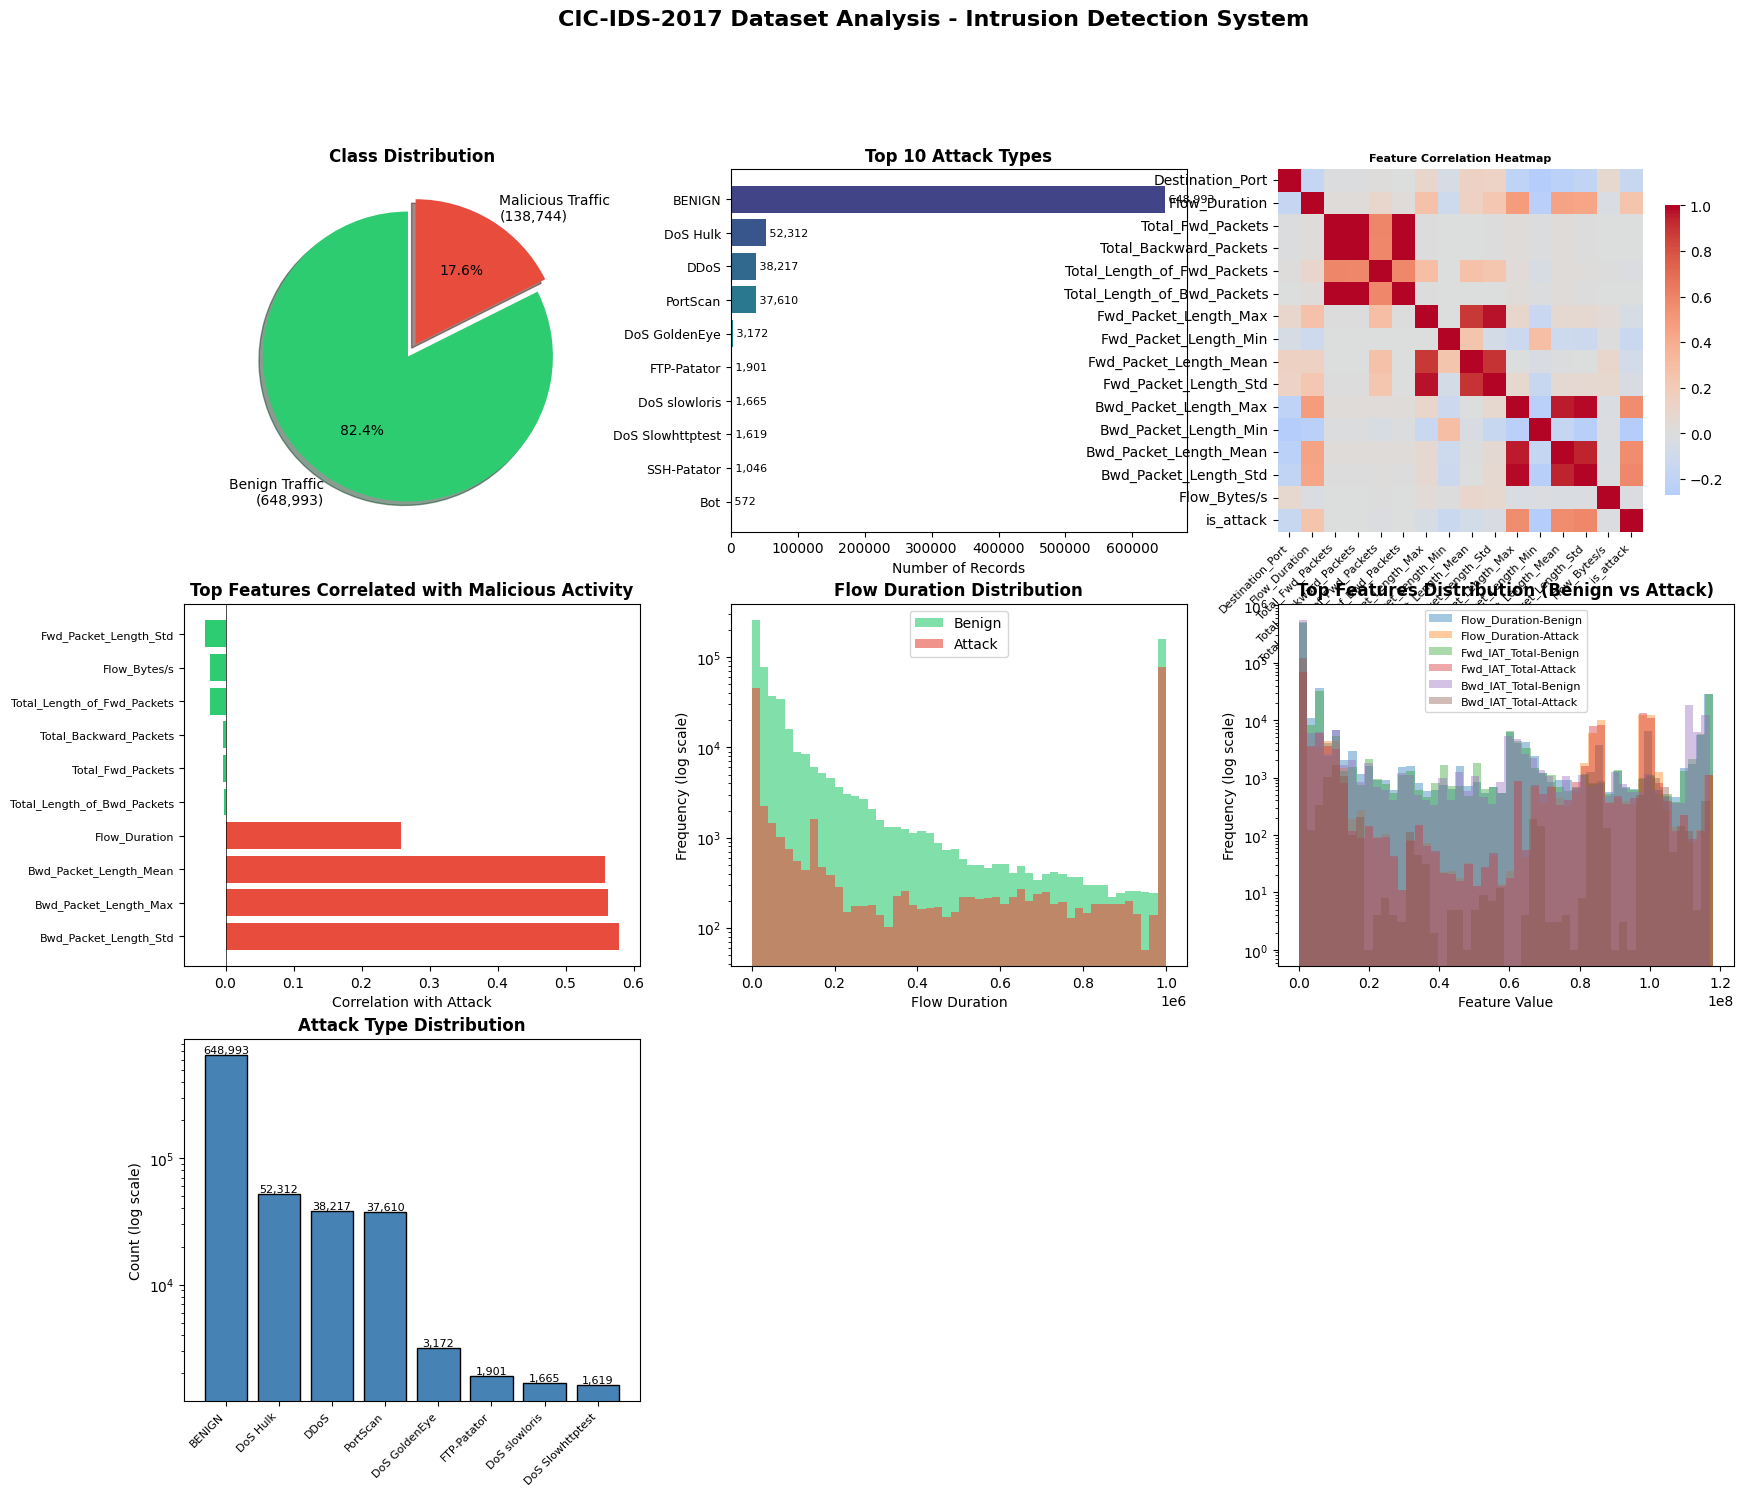


DATASET SUMMARY STATISTICS
Total Records: 787,737
Total Features: 70
Benign Traffic: 648,993 (82.4%)
Malicious Traffic: 138,744 (17.6%)
Unique Attack Types: 15

Attack Type Breakdown:
  • BENIGN: 648,993 (82.4%)
  • DoS Hulk: 52,312 (6.6%)
  • DDoS: 38,217 (4.9%)
  • PortScan: 37,610 (4.8%)
  • DoS GoldenEye: 3,172 (0.4%)
  • FTP-Patator: 1,901 (0.2%)
  • DoS slowloris: 1,665 (0.2%)
  • DoS Slowhttptest: 1,619 (0.2%)
  • SSH-Patator: 1,046 (0.1%)
  • Bot: 572 (0.1%)

✅ EDA Complete!


In [20]:
# CELL 6: Exploratory Data Analysis
import matplotlib.pyplot as plt
import seaborn as sns

def create_eda_visualizations(df_clean, feature_cols):
    """Create comprehensive EDA visualizations"""

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 16))
    fig.suptitle('CIC-IDS-2017 Dataset Analysis - Intrusion Detection System',
                 fontsize=16, fontweight='bold')

    # 1. Class Distribution Pie Chart
    ax1 = plt.subplot(3, 3, 1)
    attack_counts = df_clean['is_attack'].value_counts()
    colors = ['#2ecc71', '#e74c3c']
    explode = (0.05, 0.05)
    ax1.pie(attack_counts.values, explode=explode,
            labels=['Benign Traffic\n' + f'({attack_counts[0]:,})',
                    'Malicious Traffic\n' + f'({attack_counts[1]:,})'],
            autopct='%1.1f%%', colors=colors, shadow=True, startangle=90)
    ax1.set_title('Class Distribution', fontsize=12, fontweight='bold')

    # 2. Attack Types Distribution of Top 10
    ax2 = plt.subplot(3, 3, 2)
    attack_types = df_clean['attack_type'].value_counts().head(10)
    colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(attack_types)))
    ax2.barh(range(len(attack_types)), attack_types.values, color=colors_bar)
    ax2.set_yticks(range(len(attack_types)))
    ax2.set_yticklabels(attack_types.index, fontsize=9)
    ax2.set_xlabel('Number of Records', fontsize=10)
    ax2.set_title('Top 10 Attack Types', fontsize=12, fontweight='bold')
    ax2.invert_yaxis()

    # Add value labels
    for i, v in enumerate(attack_types.values):
        ax2.text(v, i, f' {v:,}', va='center', fontsize=8)

    # 3. Feature Correlation Heatmap of Top 15 features
    ax3 = plt.subplot(3, 3, 3)
    top_features = feature_cols[:15] if len(feature_cols) > 15 else feature_cols
    corr_matrix = df_clean[top_features + ['is_attack']].corr()
    sns.heatmap(corr_matrix, ax=ax3, cmap='coolwarm', center=0,
                annot=False, cbar_kws={'shrink': 0.8})
    ax3.set_title('Feature Correlation Heatmap', fontsize=8, fontweight='bold')
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=8)

    # 4. Top Features Correlated with Attack
    ax4 = plt.subplot(3, 3, 4)
    target_corr = corr_matrix['is_attack'].drop('is_attack').sort_values(ascending=False)
    top_corr = target_corr.head(10)
    colors_corr = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_corr.values]
    ax4.barh(range(len(top_corr)), top_corr.values, color=colors_corr)
    ax4.set_yticks(range(len(top_corr)))
    ax4.set_yticklabels(top_corr.index, fontsize=8)
    ax4.set_xlabel('Correlation with Attack', fontsize=10)
    ax4.set_title('Top Features Correlated with Malicious Activity', fontsize=12, fontweight='bold')
    ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

    # 5. Flow Duration Distribution
    ax5 = plt.subplot(3, 3, 5)
    flow_col = None
    for col in feature_cols:
        if 'flow' in col.lower() and ('duration' in col.lower() or 'dur' in col.lower()):
            flow_col = col
            break

    if flow_col:
        benign_flow = df_clean[df_clean['is_attack']==0][flow_col].clip(upper=1e6)
        attack_flow = df_clean[df_clean['is_attack']==1][flow_col].clip(upper=1e6)
        ax5.hist(benign_flow, bins=50, alpha=0.6, label='Benign', log=True, color='#2ecc71')
        ax5.hist(attack_flow, bins=50, alpha=0.6, label='Attack', log=True, color='#e74c3c')
        ax5.set_xlabel('Flow Duration', fontsize=10)
        ax5.set_ylabel('Frequency (log scale)', fontsize=10)
        ax5.set_title('Flow Duration Distribution', fontsize=12, fontweight='bold')
        ax5.legend()
    else:
        ax5.text(0.5, 0.5, 'Flow Duration column not available',
                ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title('Flow Duration Analysis', fontsize=12, fontweight='bold')

    # 6. Top Features Distribution
    ax6 = plt.subplot(3, 3, 6)
    # Get top 3 most important features by variance
    feature_vars = df_clean[feature_cols].var().sort_values(ascending=False)
    top_3_features = feature_vars.head(3).index.tolist()

    for feature in top_3_features:
        benign_vals = df_clean[df_clean['is_attack']==0][feature].clip(upper=np.percentile(df_clean[feature], 99))
        attack_vals = df_clean[df_clean['is_attack']==1][feature].clip(upper=np.percentile(df_clean[feature], 99))
        ax6.hist(benign_vals, bins=50, alpha=0.4, label=f'{feature[:20]}-Benign')
        ax6.hist(attack_vals, bins=50, alpha=0.4, label=f'{feature[:20]}-Attack')
    ax6.set_xlabel('Feature Value', fontsize=10)
    ax6.set_ylabel('Frequency (log scale)', fontsize=10)
    ax6.set_yscale('log')
    ax6.set_title('Top Features Distribution (Benign vs Attack)', fontsize=12, fontweight='bold')
    ax6.legend(fontsize=8)

    # 7. Attack Type Bar Chart
    ax7 = plt.subplot(3, 3, 7)
    class_counts = df_clean['attack_type'].value_counts().head(8)
    bars = ax7.bar(range(len(class_counts)), class_counts.values, color='steelblue', edgecolor='black')
    ax7.set_xticks(range(len(class_counts)))
    ax7.set_xticklabels(class_counts.index, rotation=45, ha='right', fontsize=8)
    ax7.set_ylabel('Count (log scale)', fontsize=10)
    ax7.set_title('Attack Type Distribution', fontsize=12, fontweight='bold')
    ax7.set_yscale('log')

    # Add value labels
    for i, v in enumerate(class_counts.values):
        ax7.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)





    # Save to drive
    os.makedirs('/content/drive/MyDrive/ids_project/visualizations', exist_ok=True)
    save_path = '/content/drive/MyDrive/ids_project/visualizations/eda_complete.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ EDA visualizations saved to: {save_path}")

    plt.show()

    # Print summary statistics
    print("\n" + "="*60)
    print("DATASET SUMMARY STATISTICS")
    print("="*60)
    print(f"Total Records: {len(df_clean):,}")
    print(f"Total Features: {len(feature_cols)}")
    print(f"Benign Traffic: {(df_clean['is_attack'] == 0).sum():,} ({(df_clean['is_attack'] == 0).sum()/len(df_clean)*100:.1f}%)")
    print(f"Malicious Traffic: {(df_clean['is_attack'] == 1).sum():,} ({(df_clean['is_attack'] == 1).sum()/len(df_clean)*100:.1f}%)")
    print(f"Unique Attack Types: {df_clean['attack_type'].nunique()}")
    print(f"\nAttack Type Breakdown:")
    for attack, count in df_clean['attack_type'].value_counts().head(10).items():
        print(f"  • {attack}: {count:,} ({count/len(df_clean)*100:.1f}%)")

    return fig

# Run EDA
if 'df_clean' in locals():
    fig = create_eda_visualizations(df_clean, feature_cols)
    print("\n✅ EDA Complete!")
else:
    print("⚠️ Please run CELL 6 first for preprocessing")

In [6]:
# CELL 7: Prepare Data for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

def prepare_ml_data(df_clean, feature_cols):
    """
    Prepare data for machine learning models
    Includes label encoding for multi-class classification
    """
    print("="*60)
    print("PREPARING DATA FOR MACHINE LEARNING")
    print("="*60)

    # Features (X) and target (y)
    X = df_clean[feature_cols].copy()
    y_binary = df_clean['is_attack'].copy()
    y_multiclass = df_clean['attack_type'].copy()

    # Handle any remaining missing values
    X = X.fillna(0)
    print(f"✓ Features shape: {X.shape}")

    # Scale features
    print("\nScaling features...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print(f"✓ Features scaled")

    # Encode multiclass labels
    print("\nEncoding multiclass labels...")
    label_encoder = LabelEncoder()
    y_multiclass_encoded = label_encoder.fit_transform(y_multiclass)

    # Print class information
    print(f"✓ Number of classes: {len(label_encoder.classes_)}")
    print(f"✓ Classes: {list(label_encoder.classes_)[:10]}")  # First 10 classes
    if len(label_encoder.classes_) > 10:
        print(f"  ... and {len(label_encoder.classes_)-10} more classes")

    # Check class distribution
    unique, counts = np.unique(y_multiclass_encoded, return_counts=True)
    print("\nClass distribution:")
    for i, (cls, count) in enumerate(zip(unique[:5], counts[:5])):
        print(f"  {label_encoder.classes_[cls]}: {count:,} samples")
    if len(unique) > 5:
        print(f"  ... and {len(unique)-5} more classes")

    # Split data for binary classification
    print("\nSplitting data (80/20)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary
    )

    # Split data for multiclass classification
    X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
        X_scaled, y_multiclass_encoded, test_size=0.2, random_state=42,
        stratify=y_multiclass_encoded
    )

    print(f"\n{'='*60}")
    print("DATA SPLIT SUMMARY")
    print('='*60)
    print(f"Binary Classification:")
    print(f"  Training: {len(X_train):,} samples")
    print(f"  Testing:  {len(X_test):,} samples")
    print(f"  Attack ratio in training: {y_train.sum()/len(y_train)*100:.1f}%")

    print(f"\nMulti-class Classification:")
    print(f"  Training: {len(X_train_mc):,} samples")
    print(f"  Testing:  {len(X_test_mc):,} samples")
    print(f"  Number of classes: {len(label_encoder.classes_)}")

    # Return ALL necessary components
    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_mc': X_train_mc,
        'X_test_mc': X_test_mc,
        'y_train_mc': y_train_mc,
        'y_test_mc': y_test_mc,
        'scaler': scaler,
        'label_encoder': label_encoder,
        'feature_names': feature_cols
    }

# Prepare data
if 'df_clean' in locals() and 'feature_cols' in locals():
    data = prepare_ml_data(df_clean, feature_cols)
    print("\n✅ Data preparation complete! 'data' dictionary contains all needed components.")
    print(f"   Keys in data: {list(data.keys())}")
else:
    print("⚠️ Please run CELL 4 and CELL 5 first to get df_clean and feature_cols")

PREPARING DATA FOR MACHINE LEARNING
✓ Features shape: (787737, 70)

Scaling features...
✓ Features scaled

Encoding multiclass labels...
✓ Number of classes: 15
✓ Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration']
  ... and 5 more classes

Class distribution:
  BENIGN: 648,993 samples
  Bot: 572 samples
  DDoS: 38,217 samples
  DoS GoldenEye: 3,172 samples
  DoS Hulk: 52,312 samples
  ... and 10 more classes

Splitting data (80/20)...

DATA SPLIT SUMMARY
Binary Classification:
  Training: 630,189 samples
  Testing:  157,548 samples
  Attack ratio in training: 17.6%

Multi-class Classification:
  Training: 630,189 samples
  Testing:  157,548 samples
  Number of classes: 15

✅ Data preparation complete! 'data' dictionary contains all needed components.
   Keys in data: ['X_train', 'X_test', 'y_train', 'y_test', 'X_train_mc', 'X_test_mc', 'y_train_mc', 'y_test_mc', 'scaler', 'label_encoder', 'fe

In [7]:
# CELL 8: Train All Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

def train_all_models(data):
    """Train all models  and compare performance"""

    models = {
        'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
        'ANN (Neural Network)': MLPClassifier(
            hidden_layer_sizes=(100, 50),
            activation='relu',
            solver='adam',
            max_iter=50,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            verbose=False
        )
    }

    results = {}

    print("="*70)
    print("MODEL TRAINING AND PERFORMANCE COMPARISON")
    print("="*70)

    for name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Training {name}...")
        print('='*50)

        start_time = time.time()

        if name == 'ANN (Neural Network)':
            print("   Training Neural Network - this may take 5-10 minutes...")

        model.fit(data['X_train'], data['y_train'])
        train_time = time.time() - start_time

        # Store predictions
        y_pred = model.predict(data['X_test'])
        y_pred_proba = model.predict_proba(data['X_test'])[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(data['y_test'], y_pred)
        precision = precision_score(data['y_test'], y_pred)
        recall = recall_score(data['y_test'], y_pred)
        f1 = f1_score(data['y_test'], y_pred)

        # Store everything in results dictionary
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'train_time': train_time,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }

        # Print metrics
        print(f"✓ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"✓ Precision: {precision:.4f} ({precision*100:.2f}%)")
        print(f"✓ Recall:    {recall:.4f} ({recall*100:.2f}%)")
        print(f"✓ F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
        print(f"✓ Training time: {train_time:.2f} seconds ({train_time/60:.2f} minutes)")

        # Confusion Matrix
        cm = confusion_matrix(data['y_test'], y_pred)
        print(f"\nConfusion Matrix:")
        print(f"  True Negatives:  {cm[0,0]:,}")
        print(f"  False Positives: {cm[0,1]:,}")
        print(f"  False Negatives: {cm[1,0]:,}")
        print(f"  True Positives:  {cm[1,1]:,}")

        # Calculate additional metrics
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
        false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

        print(f"\nDetailed Metrics:")
        print(f"  Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
        print(f"  False Positive Rate: {false_positive_rate:.4f}")
        print(f"  False Negative Rate: {false_negative_rate:.4f}")

    return results

# Train all models
if 'data' in locals():
    all_results = train_all_models(data)

    # Create comparison table
    print("\n" + "="*70)
    print("MODEL PERFORMANCE COMPARISON TABLE")
    print("="*70)
    comparison_df = pd.DataFrame([
        {
            'Model': name,
            'Accuracy': f"{results['accuracy']*100:.2f}%",
            'Precision': f"{results['precision']*100:.2f}%",
            'Recall': f"{results['recall']*100:.2f}%",
            'F1-Score': f"{results['f1_score']*100:.2f}%",
            'Time (s)': f"{results['train_time']:.1f}"
        }
        for name, results in all_results.items()
    ])
    print(comparison_df.to_string(index=False))

    # Identify best model
    best_model_name = max(all_results, key=lambda x: all_results[x]['f1_score'])
    best_f1 = all_results[best_model_name]['f1_score'] * 100
    print(f"\n{'='*70}")
    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"   F1-Score: {best_f1:.2f}%")
    print(f"{'='*70}")

    print("\n✅ All models trained successfully!")
else:
    print("⚠️ Please run CELL 8 first to prepare data")

MODEL TRAINING AND PERFORMANCE COMPARISON

Training Decision Tree...
✓ Accuracy:  0.9967 (99.67%)
✓ Precision: 0.9951 (99.51%)
✓ Recall:    0.9864 (98.64%)
✓ F1-Score:  0.9907 (99.07%)
✓ Training time: 34.86 seconds (0.58 minutes)

Confusion Matrix:
  True Negatives:  129,664
  False Positives: 135
  False Negatives: 378
  True Positives:  27,371

Detailed Metrics:
  Specificity: 0.9990 (99.90%)
  False Positive Rate: 0.0010
  False Negative Rate: 0.0136

Training Logistic Regression...
✓ Accuracy:  0.9552 (95.52%)
✓ Precision: 0.8779 (87.79%)
✓ Recall:    0.8662 (86.62%)
✓ F1-Score:  0.8720 (87.20%)
✓ Training time: 50.29 seconds (0.84 minutes)

Confusion Matrix:
  True Negatives:  126,457
  False Positives: 3,342
  False Negatives: 3,714
  True Positives:  24,035

Detailed Metrics:
  Specificity: 0.9743 (97.43%)
  False Positive Rate: 0.0257
  False Negative Rate: 0.1338

Training Random Forest...
✓ Accuracy:  0.9983 (99.83%)
✓ Precision: 0.9966 (99.66%)
✓ Recall:    0.9940 (99.40%)


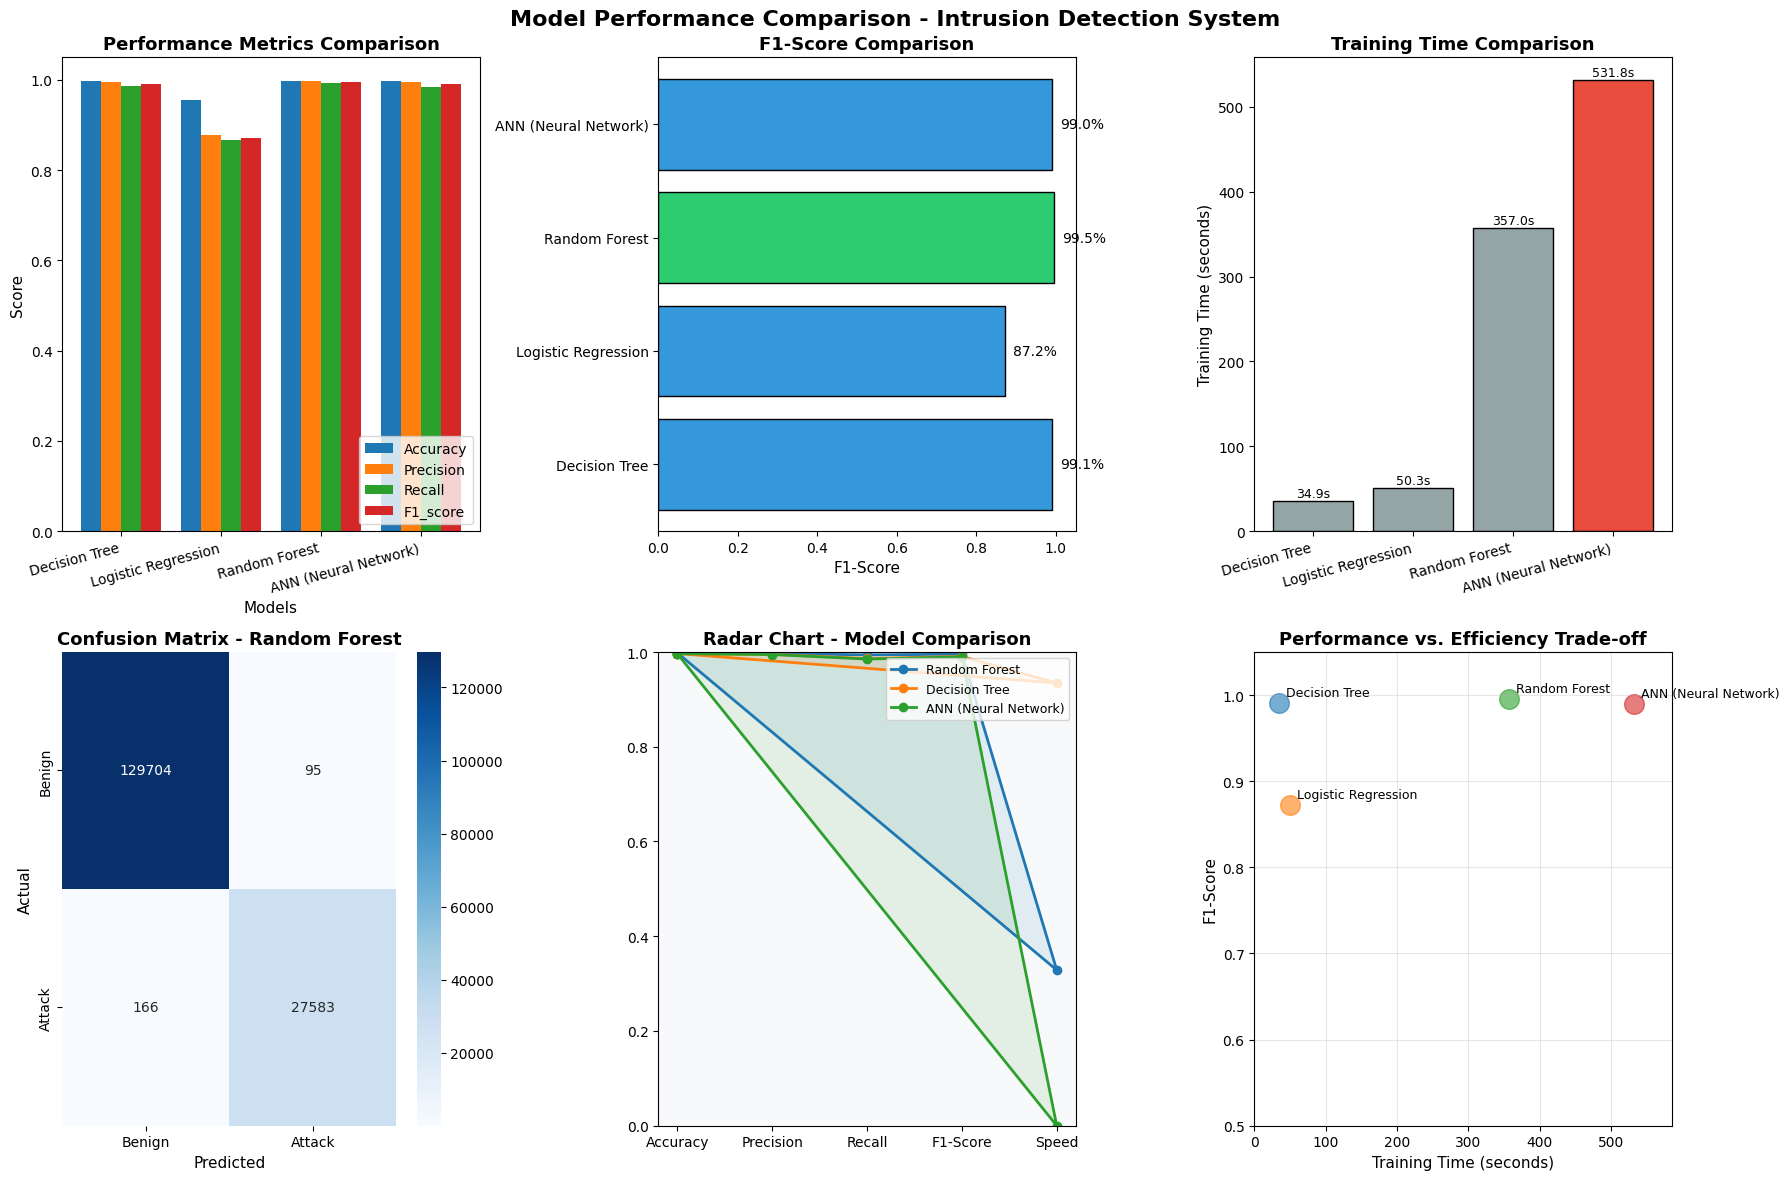


✓ Visualization saved as 'model_comparison.png'


In [8]:
# CELL 9: Visualization of Model Performance Comparison
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_model_comparison(results):
    """Create comprehensive visualization comparing all models"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Model Performance Comparison - Intrusion Detection System',
                 fontsize=16, fontweight='bold')

    # 1. Bar chart comparison of all metrics
    ax1 = axes[0, 0]
    models = list(results.keys())
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']

    x = np.arange(len(models))
    width = 0.2

    for i, metric in enumerate(metrics):
        values = [results[m][metric] for m in models]
        ax1.bar(x + i*width, values, width, label=metric.capitalize())

    ax1.set_xlabel('Models', fontsize=11)
    ax1.set_ylabel('Score', fontsize=11)
    ax1.set_title('Performance Metrics Comparison', fontsize=13, fontweight='bold')
    ax1.set_xticks(x + width * 1.5)
    ax1.set_xticklabels(models, rotation=15, ha='right')
    ax1.legend(loc='lower right')
    ax1.set_ylim(0, 1.05)

    # 2. F1-Score comparison
    ax2 = axes[0, 1]
    f1_scores = [results[m]['f1_score'] for m in models]
    colors = ['#2ecc71' if s == max(f1_scores) else '#3498db' for s in f1_scores]
    bars = ax2.barh(models, f1_scores, color=colors, edgecolor='black')
    ax2.set_xlabel('F1-Score', fontsize=11)
    ax2.set_title('F1-Score Comparison', fontsize=13, fontweight='bold')
    ax2.set_xlim(0, 1.05)

    # Add value labels
    for bar, score in zip(bars, f1_scores):
        ax2.text(score + 0.02, bar.get_y() + bar.get_height()/2,
                f'{score*100:.1f}%', va='center', fontsize=10)

    # 3. Training time comparison
    ax3 = axes[0, 2]
    train_times = [results[m]['train_time'] for m in models]
    colors_time = ['#e74c3c' if t == max(train_times) else '#95a5a6' for t in train_times]
    bars = ax3.bar(models, train_times, color=colors_time, edgecolor='black')
    ax3.set_ylabel('Training Time (seconds)', fontsize=11)
    ax3.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
    ax3.set_xticklabels(models, rotation=15, ha='right')

    # Add value labels
    for bar, time in zip(bars, train_times):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{time:.1f}s', ha='center', fontsize=9)

    # 4. Confusion Matrices Heatmap for top 2 models
    ax4 = axes[1, 0]
    best_model = max(results, key=lambda x: results[x]['f1_score'])
    cm = confusion_matrix(data['y_test'], results[best_model]['predictions'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
                xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
    ax4.set_title(f'Confusion Matrix - {best_model}', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Predicted', fontsize=11)
    ax4.set_ylabel('Actual', fontsize=11)

    # 5. Radar chart for model comparison
    ax5 = axes[1, 1]
    categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Speed']

    # Normalize metrics
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    # Plot only top 3 models for clarity
    top_models = sorted(models, key=lambda x: results[x]['f1_score'], reverse=True)[:3]

    for model_name in top_models:
        values = [
            results[model_name]['accuracy'],
            results[model_name]['precision'],
            results[model_name]['recall'],
            results[model_name]['f1_score'],
            1 - min(1, results[model_name]['train_time'] / max(train_times))  # Normalized speed
        ]
        values += values[:1]
        ax5.plot(angles, values, 'o-', linewidth=2, label=model_name)
        ax5.fill(angles, values, alpha=0.1)

    ax5.set_xticks(angles[:-1])
    ax5.set_xticklabels(categories, fontsize=10)
    ax5.set_ylim(0, 1)
    ax5.set_title('Radar Chart - Model Comparison', fontsize=13, fontweight='bold')
    ax5.legend(loc='upper right', fontsize=9)
    ax5.set_facecolor('#f8f9fa')

    # 6. Performance vs. Efficiency scatter plot
    ax6 = axes[1, 2]
    for model_name in models:
        ax6.scatter(results[model_name]['train_time'],
                   results[model_name]['f1_score'],
                   s=200, alpha=0.6, label=model_name)
        ax6.annotate(model_name,
                    (results[model_name]['train_time'], results[model_name]['f1_score']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)

    ax6.set_xlabel('Training Time (seconds)', fontsize=11)
    ax6.set_ylabel('F1-Score', fontsize=11)
    ax6.set_title('Performance vs. Efficiency Trade-off', fontsize=13, fontweight='bold')
    ax6.grid(True, alpha=0.3)
    ax6.set_xlim(0, max(train_times) * 1.1)
    ax6.set_ylim(0.5, 1.05)

    plt.tight_layout()
    plt.savefig('/content/model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✓ Visualization saved as 'model_comparison.png'")

# Run visualization
if 'all_results' in locals():
    visualize_model_comparison(all_results)

In [9]:
# CELL 10: Multi-class Attack Type Classification
from sklearn.metrics import classification_report

def train_multiclass_models(data):
    """
    Train models for multi-class attack type classification
    """
    print("\n" + "="*70)
    print("MULTI-CLASS CLASSIFICATION - Attack Type Detection")
    print("="*70)

    # Get class names and counts
    class_names = data['label_encoder'].classes_
    print(f"\nTotal attack types: {len(class_names)}")

    # Show class distribution
    unique, counts = np.unique(data['y_train_mc'], return_counts=True)
    print("\nClass distribution in training set:")
    for i, (cls, count) in enumerate(zip(unique[:15], counts[:15])):
        print(f"  {class_names[cls]}: {count:,} samples")


    models = {
        'Random Forest (Multi)': RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1),
        'Decision Tree (Multi)': DecisionTreeClassifier(max_depth=15, random_state=42),
        'ANN (Multi)': MLPClassifier(hidden_layer_sizes=(150, 75, 40), max_iter=80, random_state=42, early_stopping=True)
    }

    multiclass_results = {}

    for name, model in models.items():
        print(f"\n{'='*50}")
        print(f"Training {name}...")
        print('='*50)

        start_time = time.time()
        model.fit(data['X_train_mc'], data['y_train_mc'])
        train_time = time.time() - start_time

        y_pred = model.predict(data['X_test_mc'])

        # Calculate accuracy
        accuracy = accuracy_score(data['y_test_mc'], y_pred)

        # Get classification report
        report = classification_report(data['y_test_mc'], y_pred,
                                       target_names=class_names,
                                       output_dict=True)

        multiclass_results[name] = {
            'model': model,
            'accuracy': accuracy,
            'train_time': train_time,
            'report': report,
            'predictions': y_pred
        }

        print(f"✓ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"✓ Training time: {train_time:.2f} seconds")

        # Show weighted average metrics
        print(f"\nWeighted Average Scores:")
        print(f"  Precision: {report['weighted avg']['precision']:.4f}")
        print(f"  Recall:    {report['weighted avg']['recall']:.4f}")
        print(f"  F1-Score:  {report['weighted avg']['f1-score']:.4f}")

    return multiclass_results

# Train multi-class models
if 'data' in locals():
    multiclass_results = train_multiclass_models(data)

    # Identify best multiclass model
    best_mc = max(multiclass_results, key=lambda x: multiclass_results[x]['accuracy'])
    print(f"\n🏆 Best Multi-class Model: {best_mc}")
    print(f"   Accuracy: {multiclass_results[best_mc]['accuracy']*100:.2f}%")


MULTI-CLASS CLASSIFICATION - Attack Type Detection

Total attack types: 15

Class distribution in training set:
  BENIGN: 519,194 samples
  Bot: 458 samples
  DDoS: 30,573 samples
  DoS GoldenEye: 2,537 samples
  DoS Hulk: 41,849 samples
  DoS Slowhttptest: 1,295 samples
  DoS slowloris: 1,332 samples
  FTP-Patator: 1,521 samples
  Heartbleed: 5 samples
  Infiltration: 9 samples
  PortScan: 30,088 samples
  SSH-Patator: 837 samples
  Web Attack � Brute Force: 341 samples
  Web Attack � Sql Injection: 5 samples
  Web Attack � XSS: 145 samples

Training Random Forest (Multi)...
✓ Accuracy: 0.9981 (99.81%)
✓ Training time: 401.81 seconds

Weighted Average Scores:
  Precision: 0.9979
  Recall:    0.9981
  F1-Score:  0.9979

Training Decision Tree (Multi)...
✓ Accuracy: 0.9973 (99.73%)
✓ Training time: 48.41 seconds

Weighted Average Scores:
  Precision: 0.9971
  Recall:    0.9973
  F1-Score:  0.9970

Training ANN (Multi)...
✓ Accuracy: 0.9962 (99.62%)
✓ Training time: 820.68 seconds

Weig

In [10]:
# CELL 11: Save all trained models
import joblib
import os

def save_all_models(data, all_results, multiclass_results=None):
    """
    Save all trained models and artifacts
    """
    save_path = '/content/models/'
    os.makedirs(save_path, exist_ok=True)

    print("="*60)
    print("SAVING MODELS AND ARTIFACTS")
    print("="*60)

    # 1. Save the best binary classification model
    best_model_name = max(all_results, key=lambda x: all_results[x]['f1_score'])
    best_model = all_results[best_model_name]['model']
    joblib.dump(best_model, save_path + 'best_binary_model.pkl')
    print(f"✓ best_binary_model.pkl ({best_model_name})")

    # 2. Save all binary models
    for name, results in all_results.items():
        safe_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_')
        joblib.dump(results['model'], save_path + f'model_{safe_name}.pkl')
        print(f"✓ model_{safe_name}.pkl")

    # 3. Save scaler
    joblib.dump(data['scaler'], save_path + 'scaler.pkl')
    print("✓ scaler.pkl")

    # 4. Save label encoder
    joblib.dump(data['label_encoder'], save_path + 'label_encoder.pkl')
    print("✓ label_encoder.pkl")

    # 5. Save feature names
    joblib.dump(data['feature_names'], save_path + 'feature_names.pkl')
    print("✓ feature_names.pkl")

    # 6. Save best multi-class model if available
    if multiclass_results:
        best_mc_name = max(multiclass_results, key=lambda x: multiclass_results[x]['accuracy'])
        best_mc_model = multiclass_results[best_mc_name]['model']
        joblib.dump(best_mc_model, save_path + 'best_multiclass_model.pkl')
        print(f"✓ best_multiclass_model.pkl ({best_mc_name})")

    # 7. Save performance results as CSV
    results_df = pd.DataFrame([
        {
            'Model': name,
            'Accuracy': results['accuracy'],
            'Precision': results['precision'],
            'Recall': results['recall'],
            'F1_Score': results['f1_score'],
            'Training_Time_Seconds': results['train_time']
        }
        for name, results in all_results.items()
    ])
    results_df.to_csv(save_path + 'model_performance.csv', index=False)
    print("✓ model_performance.csv")

    # 8. Save feature importance (if Random Forest exists)
    if 'Random Forest' in all_results:
        rf_model = all_results['Random Forest']['model']
        if hasattr(rf_model, 'feature_importances_'):
            feature_importance_df = pd.DataFrame({
                'feature': data['feature_names'],
                'importance': rf_model.feature_importances_
            }).sort_values('importance', ascending=False)
            feature_importance_df.to_csv(save_path + 'feature_importance.csv', index=False)
            print("✓ feature_importance.csv")

    print("\n" + "="*60)
    print(f"All files saved to: {save_path}")

    # List all saved files
    print("\nSaved files:")
    for f in os.listdir(save_path):
        size = os.path.getsize(os.path.join(save_path, f)) / 1024
        print(f"  📁 {f} ({size:.1f} KB)")

    return save_path

# Save all models
if 'all_results' in locals() and 'data' in locals():
    save_path = save_all_models(data, all_results, multiclass_results if 'multiclass_results' in locals() else None)
else:
    print("⚠️ Please ensure 'all_results' and 'data' exist before saving")

SAVING MODELS AND ARTIFACTS
✓ best_binary_model.pkl (Random Forest)
✓ model_decision_tree.pkl
✓ model_logistic_regression.pkl
✓ model_random_forest.pkl
✓ model_ann_neural_network.pkl
✓ scaler.pkl
✓ label_encoder.pkl
✓ feature_names.pkl
✓ best_multiclass_model.pkl (Random Forest (Multi))
✓ model_performance.csv
✓ feature_importance.csv

All files saved to: /content/models/

Saved files:
  📁 model_logistic_regression.pkl (1.4 KB)
  📁 model_ann_neural_network.pkl (295.0 KB)
  📁 scaler.pkl (3.8 KB)
  📁 model_random_forest.pkl (22536.4 KB)
  📁 feature_names.pkl (1.3 KB)
  📁 best_multiclass_model.pkl (39437.9 KB)
  📁 model_decision_tree.pkl (15.9 KB)
  📁 label_encoder.pkl (0.7 KB)
  📁 best_binary_model.pkl (22536.4 KB)
  📁 feature_importance.csv (2.6 KB)
  📁 model_performance.csv (0.5 KB)


RANDOM FOREST FEATURE IMPORTANCE
                        Feature  Importance
13        Bwd_Packet_Length_Std    0.090940
12       Bwd_Packet_Length_Mean    0.070978
40       Packet_Length_Variance    0.061200
50          Average_Packet_Size    0.049465
37            Max_Packet_Length    0.045637
5   Total_Length_of_Bwd_Packets    0.043564
52         Avg_Bwd_Segment_Size    0.040616
39            Packet_Length_Std    0.039202
38           Packet_Length_Mean    0.037692
10        Bwd_Packet_Length_Max    0.031705
0              Destination_Port    0.027142
57            Subflow_Bwd_Bytes    0.022885
55            Subflow_Fwd_Bytes    0.022461
4   Total_Length_of_Fwd_Packets    0.021052
2             Total_Fwd_Packets    0.019471
54          Subflow_Fwd_Packets    0.019393
6         Fwd_Packet_Length_Max    0.018463
53          Fwd_Header_Length_1    0.018051
61         min_seg_size_forward    0.017556
44               PSH_Flag_Count    0.017192


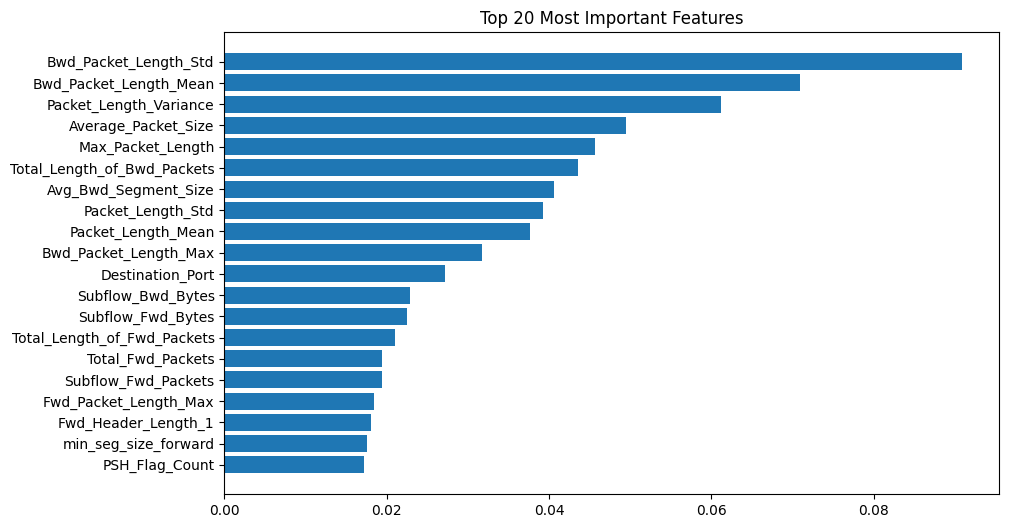

In [11]:
# CELL 12: Random Forest Feature Importance Analysis

import matplotlib.pyplot as plt

def analyze_feature_importance(all_results, data):
    """
    Analyze Random Forest Feature Importance
    """

    print("="*70)
    print("RANDOM FOREST FEATURE IMPORTANCE")
    print("="*70)

    if 'Random Forest' not in all_results:
        print("Random Forest model not found.")
        return

    rf_model = all_results['Random Forest']['model']

    importance = rf_model.feature_importances_

    feature_df = pd.DataFrame({

        "Feature": data['feature_names'],

        "Importance": importance

    })

    feature_df = feature_df.sort_values(
        by="Importance",
        ascending=False
    )

    print(feature_df.head(20))

    plt.figure(figsize=(10,6))

    plt.barh(
        feature_df["Feature"][:20],
        feature_df["Importance"][:20]
    )

    plt.title("Top 20 Most Important Features")

    plt.gca().invert_yaxis()

    plt.show()

    return feature_df


if 'all_results' in locals():

    feature_importance = analyze_feature_importance(
        all_results,
        data
    )

In [ ]:
# CELL 13: Predict New Network Traffic

import joblib

def predict_network_file(csv_path):

    print("="*70)
    print("NETWORK INTRUSION PREDICTION")
    print("="*70)

    model = joblib.load("/content/models/best_multiclass_model.pkl")

    scaler = joblib.load("/content/models/scaler.pkl")

    encoder = joblib.load("/content/models/label_encoder.pkl")

    df = pd.read_csv(csv_path)

    X = scaler.transform(df)

    prediction = model.predict(X)

    prediction_labels = encoder.inverse_transform(prediction)

    df["Predicted_Attack"] = prediction_labels

    print(df.head())

    return df

# new_prediction = predict_network_file("/content/test.csv")

In [12]:
# CELL 14: Generate Detection Report

def generate_detection_report(prediction_df):

    print("="*70)
    print("INTRUSION DETECTION REPORT")
    print("="*70)

    summary = prediction_df["Predicted_Attack"].value_counts()

    print(summary)

    plt.figure(figsize=(10,5))

    summary.plot(kind="bar")

    plt.title("Detected Attack Distribution")

    plt.ylabel("Frequency")

    plt.show()

    prediction_df.to_csv(
        "/content/models/Intrusion_Detection_Report.csv",
        index=False
    )

    print("\n✓ Report Generated Successfully")



# generate_detection_report(new_prediction)

In [13]:
# CELL 14: Generate Detection Report

def generate_detection_report(prediction_df):

    print("="*70)
    print("INTRUSION DETECTION REPORT")
    print("="*70)

    summary = prediction_df["Predicted_Attack"].value_counts()

    print(summary)

    plt.figure(figsize=(10,5))

    summary.plot(kind="bar")

    plt.title("Detected Attack Distribution")

    plt.ylabel("Frequency")

    plt.show()

    prediction_df.to_csv(
        "/content/models/Intrusion_Detection_Report.csv",
        index=False
    )

    print("\n✓ Report Generated Successfully")


# generate_detection_report(new_prediction)

In [ ]:
# CELL 15: Interactive Prediction Function

def predict_single_connection(features):

    model = joblib.load("/content/models/best_multiclass_model.pkl")

    scaler = joblib.load("/content/models/scaler.pkl")

    encoder = joblib.load("/content/models/label_encoder.pkl")

    sample = np.array(features).reshape(1,-1)

    sample = scaler.transform(sample)

    pred = model.predict(sample)

    label = encoder.inverse_transform(pred)

    print("="*60)
    print("PREDICTION RESULT")
    print("="*60)
    print(f"Detected Traffic Type : {label[0]}")

    return label[0]


# predict_single_connection(sample_features)

In [14]:
# CELL 16: Final Project Summary

def project_summary(all_results, multiclass_results):

    print("\n" + "="*70)
    print("FINAL PROJECT SUMMARY")
    print("="*70)

    print("\nBinary Classification Models\n")

    for name, result in all_results.items():

        print(f"{name}")

        print(f"Accuracy : {result['accuracy']:.4f}")

        print(f"Precision : {result['precision']:.4f}")

        print(f"Recall : {result['recall']:.4f}")

        print(f"F1 Score : {result['f1_score']:.4f}")

        print()

    print("="*70)

    if multiclass_results:

        print("\nMulti-class Models\n")

        for name, result in multiclass_results.items():

            print(f"{name}")

            print(f"Accuracy : {result['accuracy']:.4f}")

            print()

    best_binary = max(
        all_results,
        key=lambda x: all_results[x]['f1_score']
    )

    print("="*70)

    print(f"🏆 Best Binary Model : {best_binary}")

    if multiclass_results:

        best_multi = max(
            multiclass_results,
            key=lambda x: multiclass_results[x]['accuracy']
        )

        print(f"🏆 Best Multi-class Model : {best_multi}")

    print("="*70)

    print("\nProject Completed Successfully!")

if 'all_results' in locals():

    project_summary(
        all_results,
        multiclass_results if 'multiclass_results' in locals() else None
    )


FINAL PROJECT SUMMARY

Binary Classification Models

Decision Tree
Accuracy : 0.9967
Precision : 0.9951
Recall : 0.9864
F1 Score : 0.9907

Logistic Regression
Accuracy : 0.9552
Precision : 0.8779
Recall : 0.8662
F1 Score : 0.8720

Random Forest
Accuracy : 0.9983
Precision : 0.9966
Recall : 0.9940
F1 Score : 0.9953

ANN (Neural Network)
Accuracy : 0.9964
Precision : 0.9947
Recall : 0.9851
F1 Score : 0.9898


Multi-class Models

Random Forest (Multi)
Accuracy : 0.9981

Decision Tree (Multi)
Accuracy : 0.9973

ANN (Multi)
Accuracy : 0.9962

🏆 Best Binary Model : Random Forest
🏆 Best Multi-class Model : Random Forest (Multi)

Project Completed Successfully!


In [19]:
#Cell 17
import pandas as pd
from google.colab import files

# Your data should be in df_clean
print(f"Total rows: {len(df_clean)}")
print(f"Attack types: {df_clean['attack_type'].value_counts()}")

# Generate 5 different CSVs with different random states
for i, seed in enumerate([42, 43, 44, 45, 46]):
    print(f"\n📊 Generating CSV {i+1} with random_state={seed}")

    # Sample benign
    benign = df_clean[df_clean['is_attack'] == 0].sample(5, random_state=seed)

    # Sample attacks (2 from each type)
    attacks = df_clean[df_clean['is_attack'] == 1]
    attack_samples = []
    for attack_type in attacks['attack_type'].unique():
        sample = attacks[attacks['attack_type'] == attack_type].head(2)
        attack_samples.append(sample)
    attacks_sample = pd.concat(attack_samples)

    # Combine
    test_data = pd.concat([benign, attacks_sample])

    # Remove target columns
    if 'is_attack' in test_data.columns:
        test_data = test_data.drop('is_attack', axis=1)
    if 'attack_type' in test_data.columns:
        test_data = test_data.drop('attack_type', axis=1)
    if 'Label' in test_data.columns:
        test_data = test_data.drop('Label', axis=1)

    # Save
    filename = f'test_data_seed_{seed}.csv'
    test_data.to_csv(filename, index=False)

    # Download
    files.download(filename)

    print(f"✅ Downloaded: {filename} ({len(test_data)} rows)")
    print(f"   Attack types: {attacks_sample['attack_type'].value_counts().to_dict()}")


Total rows: 787737
Attack types: attack_type
BENIGN                        648993
DoS Hulk                       52312
DDoS                           38217
PortScan                       37610
DoS GoldenEye                   3172
FTP-Patator                     1901
DoS slowloris                   1665
DoS Slowhttptest                1619
SSH-Patator                     1046
Bot                              572
Web Attack � Brute Force         426
Web Attack � XSS                 181
Infiltration                      11
Heartbleed                         6
Web Attack � Sql Injection         6
Name: count, dtype: int64

📊 Generating CSV 1 with random_state=42


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: test_data_seed_42.csv (33 rows)
   Attack types: {'DDoS': 2, 'DoS Hulk': 2, 'PortScan': 2, 'DoS slowloris': 2, 'Bot': 2, 'SSH-Patator': 2, 'FTP-Patator': 2, 'DoS GoldenEye': 2, 'DoS Slowhttptest': 2, 'Web Attack � Brute Force': 2, 'Web Attack � XSS': 2, 'Heartbleed': 2, 'Infiltration': 2, 'Web Attack � Sql Injection': 2}

📊 Generating CSV 2 with random_state=43


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: test_data_seed_45.csv (33 rows)
   Attack types: {'DDoS': 2, 'DoS Hulk': 2, 'PortScan': 2, 'DoS slowloris': 2, 'Bot': 2, 'SSH-Patator': 2, 'FTP-Patator': 2, 'DoS GoldenEye': 2, 'DoS Slowhttptest': 2, 'Web Attack � Brute Force': 2, 'Web Attack � XSS': 2, 'Heartbleed': 2, 'Infiltration': 2, 'Web Attack � Sql Injection': 2}

📊 Generating CSV 5 with random_state=46


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: test_data_seed_46.csv (33 rows)
   Attack types: {'DDoS': 2, 'DoS Hulk': 2, 'PortScan': 2, 'DoS slowloris': 2, 'Bot': 2, 'SSH-Patator': 2, 'FTP-Patator': 2, 'DoS GoldenEye': 2, 'DoS Slowhttptest': 2, 'Web Attack � Brute Force': 2, 'Web Attack � XSS': 2, 'Heartbleed': 2, 'Infiltration': 2, 'Web Attack � Sql Injection': 2}
